In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import torchvision

In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Будем использовать: {device}")

MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

Будем использовать: cpu


In [ ]:
# Аугментация
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

# Создаем Dataset
data_dir = '../data/processed'

train_dataset = datasets.ImageFolder(root=f'{data_dir}/train', transform=train_transforms)
val_dataset = datasets.ImageFolder(root=f'{data_dir}/val', transform=val_transforms)

print(f"Картинок в train: {len(train_dataset)}")
print(f"Картинок в val: {len(val_dataset)}")
print(f"Наши классы: {train_dataset.classes}")

# 3. Создаем DataLoader
BATCH_SIZE = 32 #

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

Картинок в train: 2056
Картинок в val: 517
Наши классы: ['bathroom', 'bedroom', 'dining_room', 'kitchen', 'livingroom']


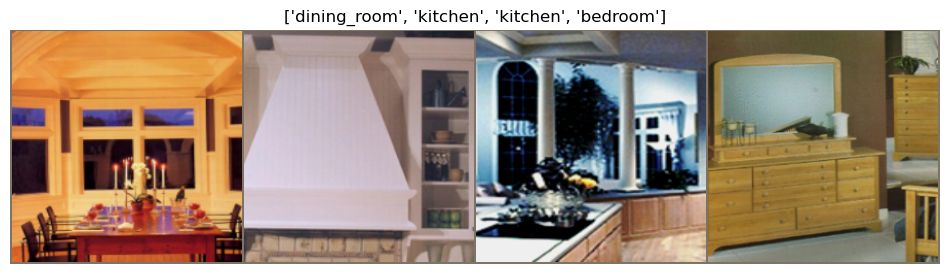

In [5]:
def imshow(inp, title=None):
    """Функция для денормализации и показа тензора-картинки"""
    inp = inp.numpy().transpose((1, 2, 0))
    inp = STD * inp + MEAN 
    inp = np.clip(inp, 0, 1)
    
    plt.figure(figsize=(12, 12))
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.axis('off')
    plt.show()

inputs, classes = next(iter(train_loader))

out = torchvision.utils.make_grid(inputs[:4])
imshow(out, title=[train_dataset.classes[x] for x in classes[:4]])